# Ejercicio 2 — catch22

Extracción de las 22 características de *catch22* para las 7 series construidas en el Laboratorio 1 (total + 3 vías + 3 regiones), matriz de características, estandarización, PCA, clustering, heatmap, correlación entre características, mapa de distancias, y un modelo LSTM alimentado con características catch22 (punto 2.14).

In [1]:
import sys
sys.path.insert(0, ".")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pycatch22
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from statsmodels.tsa.seasonal import seasonal_decompose

from datos_comunes import cargar_series

OUT_DIR = "resultados"
np.random.seed(42)

## Datos: las 7 series completas (train + test)

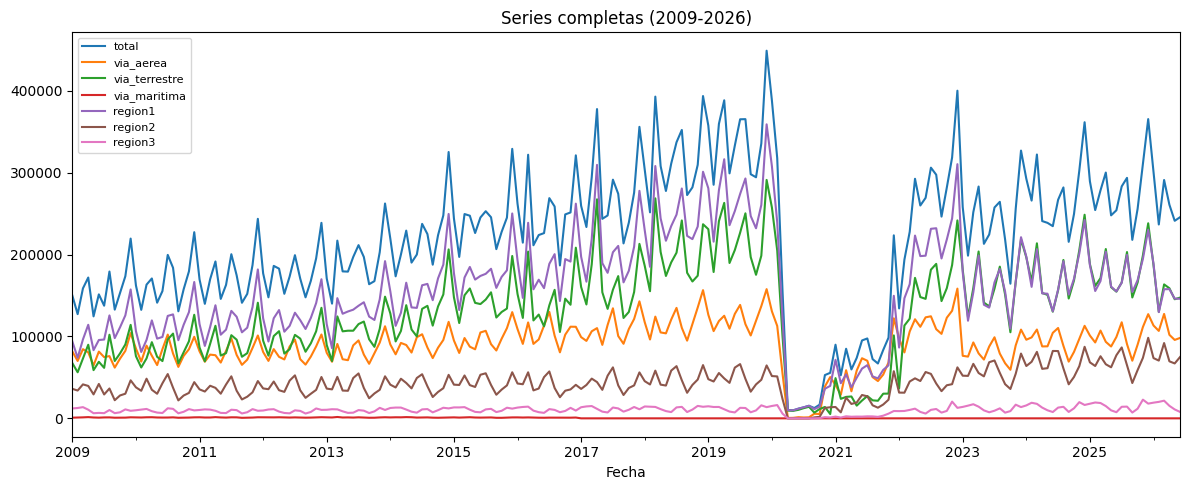

In [2]:
series_train, series_test, labels = cargar_series()
nombres = list(labels.keys())
completas = {n: pd.concat([series_train[n], series_test[n]]).sort_index() for n in nombres}

fig, ax = plt.subplots(figsize=(12, 5))
for n in nombres:
    completas[n].plot(ax=ax, label=n)
ax.set_title("Series completas (2009-2026)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2.2 y 2.3 — Extracción de las 22 características de catch22

Se calcula `pycatch22.catch22_all` sobre cada serie completa y se arma la matriz series × características.

In [3]:
filas = {}
nombres_features = None
for n in nombres:
    res = pycatch22.catch22_all(list(completas[n].astype(float).values))
    filas[n] = res["values"]
    nombres_features = res["names"]

matriz = pd.DataFrame(filas, index=nombres_features).T
matriz.index.name = "serie"
matriz.to_csv(f"{OUT_DIR}/ej2_features.csv")
matriz.round(3)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
total,0.083,0.342,8.965,3.0,0.352,-0.062,0.933,30.0,0.014,11.0,...,0.056,0.210,0.324,0.820,6.0,1.852,0.833,0.857,0.123,0.626
via_aerea,-0.398,-0.115,6.591,10.0,0.206,-0.163,0.957,34.0,0.010,11.0,...,0.071,0.186,0.324,0.758,5.0,2.001,0.857,0.857,0.172,0.739
via_terrestre,0.277,-0.193,9.573,2.0,0.484,-0.025,0.933,29.0,0.014,3.0,...,0.056,0.219,0.329,0.818,6.0,1.782,0.833,0.857,0.098,0.616
via_maritima,-0.577,-0.729,41.892,6.0,0.667,-0.040,0.450,96.0,0.074,7.0,...,0.014,-0.552,0.462,0.945,4.0,1.205,0.167,0.786,0.025,0.323
region1,0.391,0.128,8.866,3.0,0.400,-0.065,0.919,42.0,0.014,7.0,...,0.056,0.171,0.324,0.815,6.0,1.833,0.786,0.857,0.123,0.635
region2,0.311,-0.239,9.077,2.0,0.271,-0.012,0.943,12.0,0.036,3.0,...,0.038,0.829,0.324,0.740,5.0,2.053,0.167,0.738,0.098,0.722
region3,0.268,0.008,4.448,2.0,0.348,0.084,0.943,8.0,0.014,8.0,...,0.059,0.819,0.333,0.762,6.0,2.055,0.143,0.738,0.172,0.783


## 2.4 — Estandarización de las características

In [4]:
scaler = StandardScaler()
matriz_std = pd.DataFrame(scaler.fit_transform(matriz), index=matriz.index, columns=matriz.columns)
matriz_std.to_csv(f"{OUT_DIR}/ej2_features_std.csv")
matriz_std.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,
total,0.09,1.46,-0.32,-0.36,-0.27,-0.32,0.38,-0.22,-0.53,1.27,...,0.33,-0.14,-0.46,0.18,0.78,0.09,0.88,0.83,0.15,-0.06
via_aerea,-1.27,-0.00,-0.51,2.16,-1.31,-1.79,0.52,-0.07,-0.69,1.27,...,1.26,-0.19,-0.46,-0.79,-0.59,0.64,0.95,0.83,1.20,0.74
via_terrestre,0.64,-0.25,-0.27,-0.72,0.67,0.23,0.38,-0.25,-0.53,-1.36,...,0.33,-0.11,-0.36,0.15,0.78,-0.16,0.88,0.83,-0.37,-0.14
via_maritima,-1.77,-1.97,2.43,0.72,1.98,-0.00,-2.44,2.23,2.27,-0.05,...,-2.09,-1.90,2.44,2.15,-1.96,-2.27,-1.13,-0.51,-1.95,-2.22
region1,0.96,0.78,-0.33,-0.36,0.07,-0.36,0.30,0.23,-0.53,-0.05,...,0.33,-0.22,-0.46,0.11,0.78,0.03,0.74,0.83,0.15,-0.00
region2,0.74,-0.40,-0.31,-0.72,-0.85,0.42,0.44,-0.89,0.52,-1.36,...,-0.68,1.29,-0.46,-1.07,-0.59,0.83,-1.13,-1.41,-0.37,0.62
region3,0.61,0.39,-0.69,-0.72,-0.30,1.82,0.44,-1.03,-0.52,0.28,...,0.52,1.27,-0.26,-0.73,0.78,0.84,-1.20,-1.41,1.20,1.06


## 2.5 — PCA

Varianza explicada: PC1=58.8%  PC2=22.3%


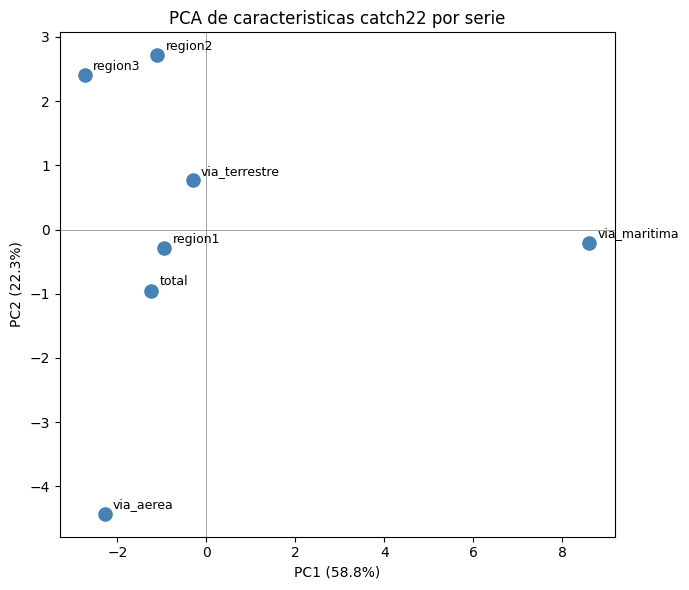

In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(matriz_std)
df_pca = pd.DataFrame(coords, index=matriz.index, columns=["PC1", "PC2"])
df_pca.to_csv(f"{OUT_DIR}/ej2_pca.csv")
print(f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}")

loadings = pd.DataFrame(pca.components_.T, index=matriz.columns, columns=["PC1", "PC2"])
loadings.to_csv(f"{OUT_DIR}/ej2_pca_loadings.csv")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_pca["PC1"], df_pca["PC2"], s=90, color="steelblue")
for n in matriz.index:
    ax.annotate(n, (df_pca.loc[n, "PC1"], df_pca.loc[n, "PC2"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA de caracteristicas catch22 por serie")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ej2_pca.png", dpi=120)
plt.show()

In [6]:
print("Caracteristicas con mayor peso en PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print("\nCaracteristicas con mayor peso en PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

Caracteristicas con mayor peso en PC1:
CO_f1ecac                        0.276876
MD_hrv_classic_pnn40             0.273534
DN_OutlierInclude_n_001_mdrmd    0.269415
SB_MotifThree_quantile_hh        0.268583
FC_LocalSimple_mean3_stderr      0.267809
Name: PC1, dtype: float64

Caracteristicas con mayor peso en PC2:
CO_trev_1_num                              0.408469
CO_FirstMin_ac                             0.392788
IN_AutoMutualInfoStats_40_gaussian_fmmi    0.392437
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1     0.325441
PD_PeriodicityWang_th0_01                  0.315859
Name: PC2, dtype: float64


## Clustering: dendrograma (jerárquico) y KMeans

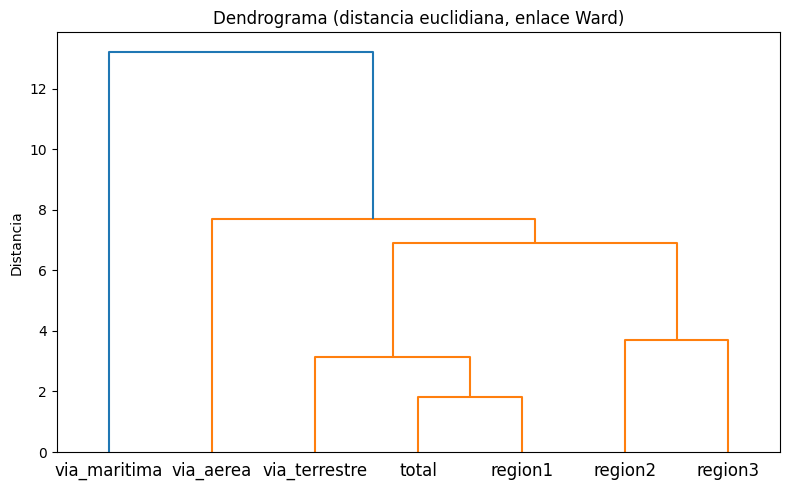

In [7]:
Z = linkage(matriz_std.values, method="ward")
fig, ax = plt.subplots(figsize=(8, 5))
dendrogram(Z, labels=list(matriz.index), ax=ax)
ax.set_title("Dendrograma (distancia euclidiana, enlace Ward)")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ej2_dendrograma.png", dpi=120)
plt.show()

In [8]:
mejor_k, mejor_sil = 2, -1
for k in range(2, min(5, len(matriz) - 1) + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(matriz_std)
    sil = silhouette_score(matriz_std, km.labels_)
    print(f"KMeans k={k}  silhouette={sil:.3f}")
    if sil > mejor_sil:
        mejor_k, mejor_sil = k, sil

km = KMeans(n_clusters=mejor_k, random_state=42, n_init=10).fit(matriz_std)
df_clusters = pd.DataFrame({"serie": matriz.index, "cluster": km.labels_})
df_clusters.to_csv(f"{OUT_DIR}/ej2_clusters.csv", index=False)
print(f"\nMejor k por silhouette: {mejor_k}")
df_clusters

KMeans k=2  silhouette=0.460
KMeans k=3  silhouette=0.259
KMeans k=4  silhouette=0.295
KMeans k=5  silhouette=0.210

Mejor k por silhouette: 2


,serie,cluster
0,total,0
1,via_aerea,0
2,via_terrestre,0
3,via_maritima,1
4,region1,0
5,region2,0
6,region3,0


## Heatmap de características estandarizadas

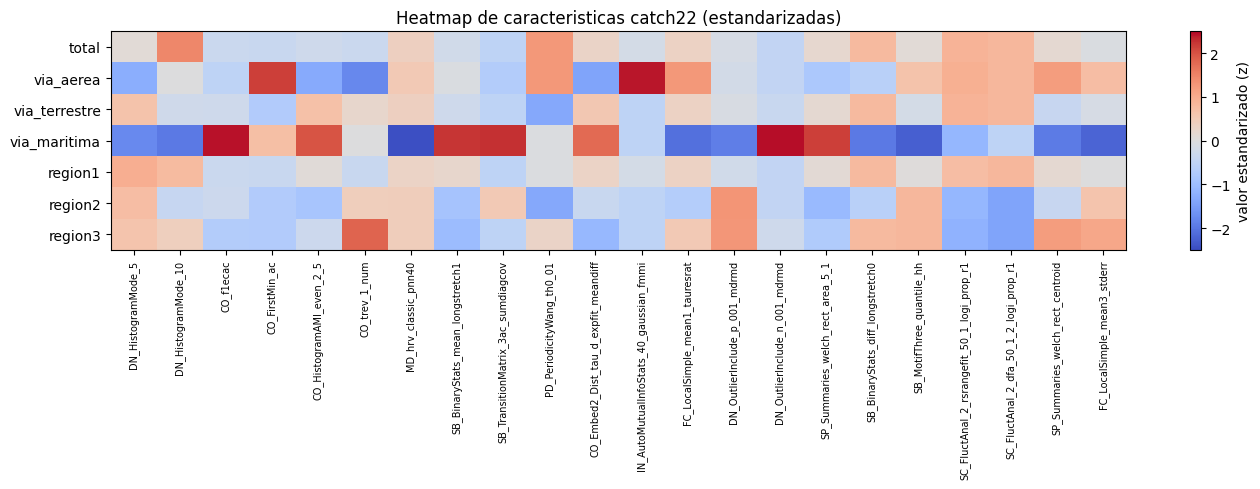

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(matriz_std.values, aspect="auto", cmap="coolwarm", vmin=-2.5, vmax=2.5)
ax.set_xticks(range(len(matriz_std.columns)))
ax.set_xticklabels(matriz_std.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(matriz_std.index)))
ax.set_yticklabels(matriz_std.index)
plt.colorbar(im, ax=ax, label="valor estandarizado (z)")
ax.set_title("Heatmap de caracteristicas catch22 (estandarizadas)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ej2_heatmap.png", dpi=120)
plt.show()

## Matriz de correlación entre características

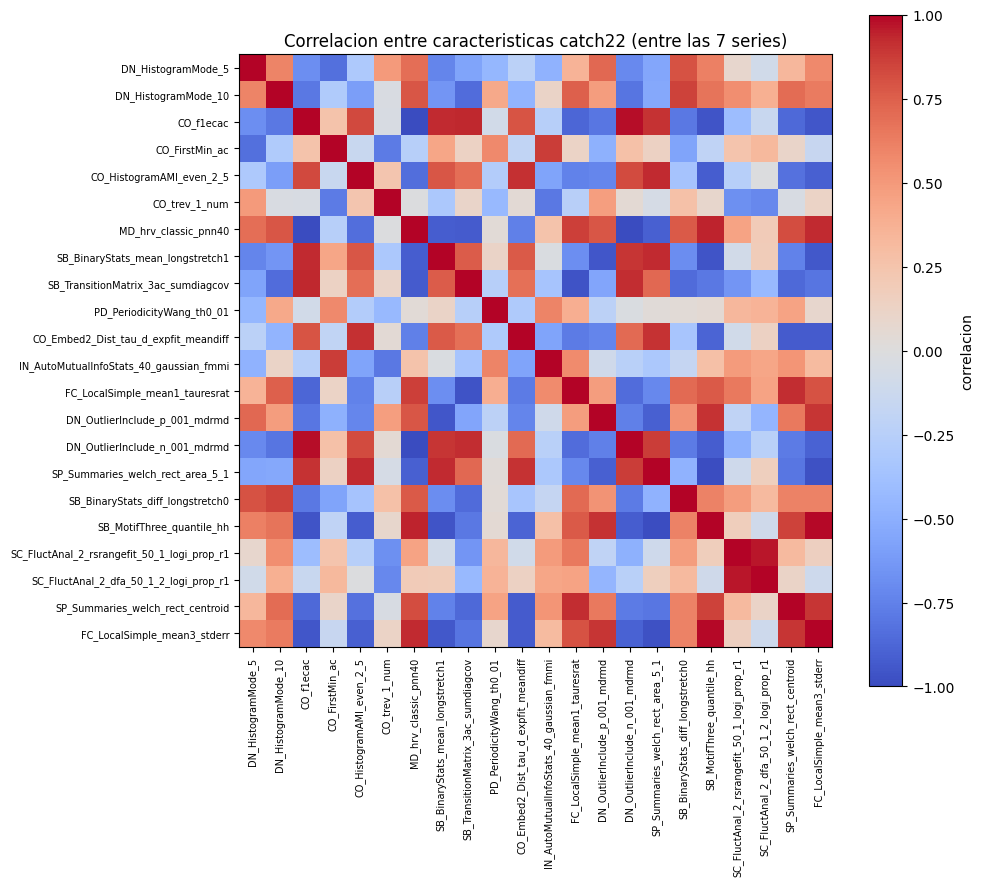

In [10]:
corr = matriz.corr()
corr.to_csv(f"{OUT_DIR}/ej2_corr_features.csv")
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im, ax=ax, label="correlacion")
ax.set_title("Correlacion entre caracteristicas catch22 (entre las 7 series)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ej2_corr.png", dpi=120)
plt.show()

## Mapa de distancias entre series

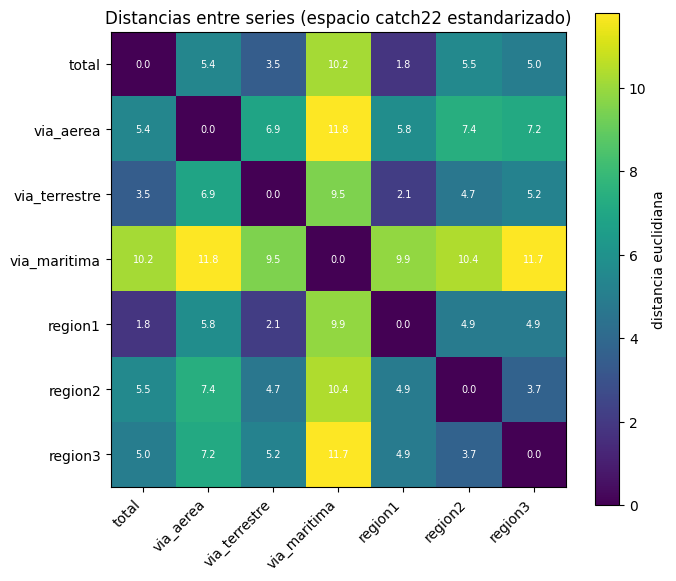

Distancia media de cada serie al resto (mayor = mas atipica):


serie
via_maritima     9.072768
via_aerea        6.331437
region3          5.385653
region2          5.221756
via_terrestre    4.550815
total            4.492236
region1          4.199184
dtype: float64

In [11]:
dist = squareform(pdist(matriz_std.values, metric="euclidean"))
df_dist = pd.DataFrame(dist, index=matriz.index, columns=matriz.index)
df_dist.to_csv(f"{OUT_DIR}/ej2_distancias.csv")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(df_dist.values, cmap="viridis")
ax.set_xticks(range(len(df_dist.columns)))
ax.set_xticklabels(df_dist.columns, rotation=45, ha="right")
ax.set_yticks(range(len(df_dist.columns)))
ax.set_yticklabels(df_dist.columns)
for i in range(len(df_dist)):
    for j in range(len(df_dist)):
        ax.text(j, i, f"{df_dist.values[i, j]:.1f}", ha="center", va="center", color="white", fontsize=7)
plt.colorbar(im, ax=ax, label="distancia euclidiana")
ax.set_title("Distancias entre series (espacio catch22 estandarizado)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ej2_distancias.png", dpi=120)
plt.show()

print("Distancia media de cada serie al resto (mayor = mas atipica):")
df_dist.mean().sort_values(ascending=False)

## Métricas de EDA para comparar con catch22 (insumo para 2.12)

Tendencia, estacionalidad, volatilidad e impacto de la pandemia, calculadas con la misma lógica del análisis exploratorio del Laboratorio 1, sobre el train actual (147 meses).

In [12]:
filas_eda = []
for n in nombres:
    train = series_train[n]
    completa = completas[n]
    if (train <= 0).sum() > len(train) * 0.3:
        filas_eda.append({"serie": n, "label": labels[n], "fuerza_tendencia": np.nan,
                           "fuerza_estacionalidad": np.nan, "volatilidad_pct": np.nan,
                           "impacto_pandemia_pct": np.nan, "nota": "serie degenerada (>30% meses en cero)"})
        continue
    log_train = np.log1p(train)
    decomp = seasonal_decompose(log_train, model="additive", period=12)
    resid = decomp.resid.dropna()
    trend = decomp.trend.dropna()
    seasonal = decomp.seasonal.loc[resid.index]
    trend_r = trend.loc[resid.index]
    var_resid = resid.var()
    f_trend = max(0, 1 - var_resid / (trend_r + resid).var())
    f_seasonal = max(0, 1 - var_resid / (seasonal + resid).var())
    volatilidad = np.log1p(train).diff().dropna().std() * 100
    total_2019 = completa["2019-01":"2019-12"].sum()
    total_2020 = completa["2020-01":"2020-12"].sum()
    impacto_pandemia = (total_2020 / total_2019 - 1) * 100 if total_2019 else np.nan
    filas_eda.append({"serie": n, "label": labels[n], "fuerza_tendencia": f_trend,
                       "fuerza_estacionalidad": f_seasonal, "volatilidad_pct": volatilidad,
                       "impacto_pandemia_pct": impacto_pandemia, "nota": ""})

tabla_eda = pd.DataFrame(filas_eda)
tabla_eda.to_csv(f"{OUT_DIR}/ej2_eda_comparativo.csv", index=False)
tabla_eda

,serie,label,fuerza_tendencia,fuerza_estacionalidad,volatilidad_pct,impacto_pandemia_pct,nota
0,total,Total mensual de viajeros (Turista+Excursionista),0.783473,0.225739,32.738069,-74.353675,
1,via_aerea,Viajeros por vía Aérea,0.706638,0.147637,48.746620,-72.797037,
2,via_terrestre,Viajeros por vía Terrestre,0.818123,0.287647,38.472822,-75.225405,
3,via_maritima,Viajeros por vía Marítima,NaN,NaN,NaN,NaN,serie degenerada (>30% meses en cero)
4,region1,Viajeros por región: América Del Centro,0.791784,0.245073,31.933866,-74.431095,
5,region2,Viajeros por región: América Del Norte,0.637419,0.093924,107.378497,-74.144309,
6,region3,Viajeros por región: Europa,0.716636,0.187690,85.921201,-71.829700,


## 2.14 — LSTM con características catch22 (rolling) vs. mejor LSTM del Ejercicio 1

En vez de recibir los valores crudos de la ventana, el modelo recibe las 22 características catch22 calculadas sobre ventanas de 12 meses, usando las últimas 3 ventanas consecutivas para predecir el mes siguiente. Se compara contra el mejor LSTM "clásico" (ventana de valores crudos) de la serie `total`.

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42)

SERIE = "total"
VENTANA = 12
LOOKBACK = 3

def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

train, test = series_train[SERIE], series_test[SERIE]
completa = completas[SERIE]
n_train = len(train)

valores = completa.values.astype(float)
feats, targets, idx_target = [], [], []
for t in range(VENTANA, len(valores) - 1):
    ventana_vals = valores[t - VENTANA:t]
    res = pycatch22.catch22_all(list(ventana_vals))
    feats.append(res["values"])
    targets.append(valores[t + 1])
    idx_target.append(t + 1)
feats = np.array(feats)
targets = np.array(targets)
idx_target = np.array(idx_target)

X, y, idx_y = [], [], []
for i in range(LOOKBACK, len(feats)):
    X.append(feats[i - LOOKBACK:i])
    y.append(targets[i])
    idx_y.append(idx_target[i])
X = np.array(X)
y = np.array(y)
idx_y = np.array(idx_y)

es_train = idx_y < n_train
X_train, y_train = X[es_train], y[es_train]
X_test, y_test = X[~es_train], y[~es_train]
fechas_test = completa.index[idx_y[~es_train]]

n_feat = X_train.shape[2]
scaler_x = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train_s = scaler_x.transform(X_train.reshape(-1, n_feat)).reshape(X_train.shape)
X_test_s = scaler_x.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

scaler_y = MinMaxScaler().fit(y_train.reshape(-1, 1))
y_train_s = scaler_y.transform(y_train.reshape(-1, 1))

n_val = max(10, int(len(X_train_s) * 0.2))
x_tr, y_tr = X_train_s[:-n_val], y_train_s[:-n_val]
x_val, y_val = X_train_s[-n_val:], y_train_s[-n_val:]

modelo = Sequential([Input(shape=(LOOKBACK, n_feat)), LSTM(32), Dense(1)])
modelo.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
es = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
modelo.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=150, batch_size=16, verbose=0, callbacks=[es])

pred_s = modelo.predict(X_test_s, verbose=0)
pred = scaler_y.inverse_transform(pred_s).flatten()
mae, rmse = evaluar(y_test, pred)
print(f"LSTM + catch22 rolling (serie={SERIE}): test MAE={mae:,.0f}  RMSE={rmse:,.0f}")

LSTM + catch22 rolling (serie=total): test MAE=236,903  RMSE=289,520


Mejor LSTM clasico (Ejercicio 1, serie=total): MAE=35,687  RMSE=46,500


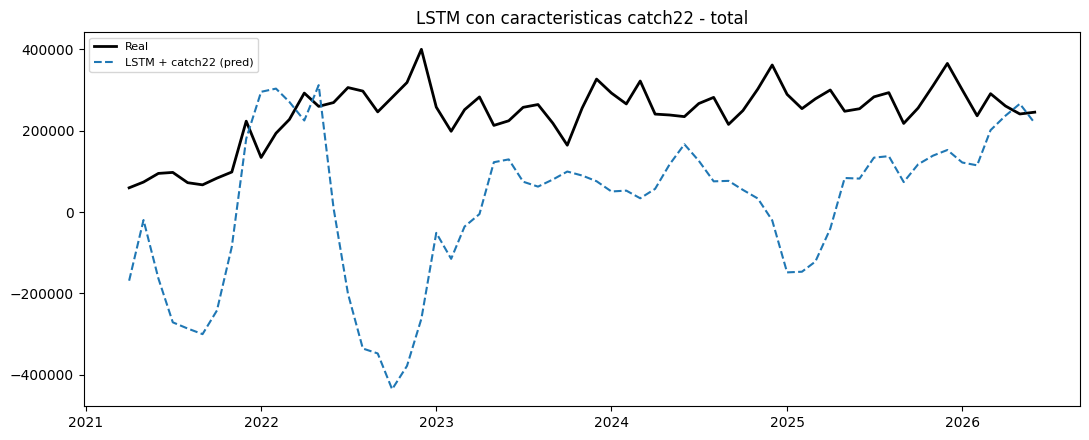

,modelo,MAE,RMSE
0,LSTM (ventana de valores crudos) - mejor de Ej...,35687.197334,46499.837002
1,LSTM + caracteristicas catch22 (rolling),236903.276279,289520.044132


In [14]:
finales = pd.read_csv(f"{OUT_DIR}/ej1_finales.csv")
fila_mejor = finales[(finales["serie"] == SERIE) & (finales["es_mejor"])].iloc[0]
print(f"Mejor LSTM clasico (Ejercicio 1, serie={SERIE}): "
      f"MAE={fila_mejor['test_MAE']:,.0f}  RMSE={fila_mejor['test_RMSE']:,.0f}")

resumen = pd.DataFrame([
    {"modelo": "LSTM (ventana de valores crudos) - mejor de Ejercicio 1",
     "MAE": fila_mejor["test_MAE"], "RMSE": fila_mejor["test_RMSE"]},
    {"modelo": "LSTM + caracteristicas catch22 (rolling)", "MAE": mae, "RMSE": rmse},
])
resumen.to_csv(f"{OUT_DIR}/ej2_lstm_catch22_comparacion.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(fechas_test, y_test, label="Real", color="black", lw=2)
ax.plot(fechas_test, pred, "--", label="LSTM + catch22 (pred)")
ax.set_title(f"LSTM con caracteristicas catch22 - {SERIE}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ej2_lstm_catch22_pred.png", dpi=120)
plt.show()

resumen